# Data Tranformation(DGS_Reduction)

# Load data as Scipp DataArray (McStasToX)

In [2]:
import os
import sys
import scipp as sc
import mcstastox as mx

parent = os.path.dirname(os.getcwd())
sys.path.append(parent)

data_path = parent + "/runs/CSPEC_vanad_1e10"

with mx.Read(data_path) as mcstas_data:
    scipp_data_group = mcstas_data.export_scipp(
        source_name="ESS_Source",
        sample_name="Sample",
    )
display(scipp_data_group)
det_positions = scipp_data_group["positions"]

DataGroup(sizes={'pixel_id': None, 'panel_id': 1, 'pixel': 2}, keys=[
    events: DataArray({'pixel_id': 31499}),
    positions: Variable({'pixel_id': 44800}),
    bank_ids: Variable({'panel_id': 1, 'pixel': 2}),
    bank_names: Variable({'panel_id': 1}),
])

The events are binned by pixel_id, only pixels with events recored are saved in data. This allows for masking by pixel_id 

In [3]:
events_binned = scipp_data_group["events"]
display(events_binned)
sample_position = events_binned.coords["sample_position"]

# mask back scattering pixels
# mask = events_binned.coords["position"].fields.z > sample_position.fields.z
# events_binned = events_binned[mask]

<scipp.DataArray>
Dimensions: Sizes[pixel_id:31499, ]
Coordinates:
* pixel_id                    int64  [dimensionless]  (pixel_id)  [0, 1, ..., 44703, 44704]
* position                  vector3              [m]  (pixel_id)  [(-1.65177, -2.18399, 162.804), (-1.62368, -2.18399, 162.824), ..., (3.87779, 1.29157, 159.954), (3.87763, 1.29157, 159.919)]
* sample_position           vector3              [m]  ()  (0.37797, -0.446287, 159.953)
* source_position           vector3              [m]  ()  (0, 0, 0)
Data:
                          DataArrayView        <no unit>  (pixel_id)  binned data: dim='events', content=DataArray(
          dims=(events: 1793080),
          data=float64[counts],
          coords={'t':float64[s]})

# Read in Monitor data (McStasScript/McStasToX)

In [4]:
import mcstasscript as ms
from reduction.dgs_reduction import monitor_multi_pulse

mcstas_data = ms.load_data(data_path)
presample_monitor_data = ms.name_search("TOF_Sample_AllLambda_zoom", mcstas_data)
monitor_data = monitor_multi_pulse(presample_monitor_data, rrm=5,threshold_fraction=0.2)


  Expected ~5 frames (RRM=5)
  Detected 5 peaks
  Min distance used: 1 bins (5499450.0 µs)
    Peak  0: t=98709064418.55 µs  counts=8.614e+05
    Peak  1: t=110723096863.13 µs  counts=1.519e+06
    Peak  2: t=122736834707.36 µs  counts=1.484e+06
    Peak  3: t=134750577529.76 µs  counts=1.426e+06
    Peak  4: t=146764314175.32 µs  counts=1.333e+06


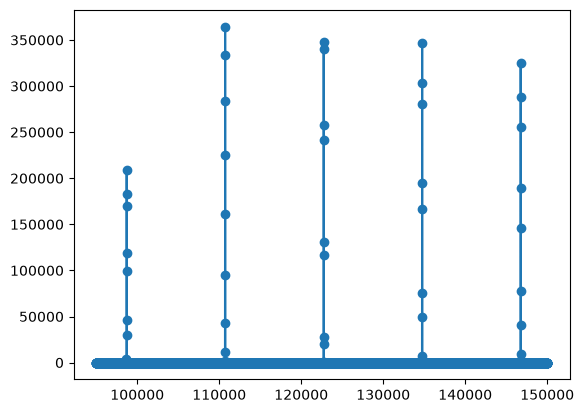

In [8]:
import numpy as np
import matplotlib.pyplot as plt

intensity = np.asarray(presample_monitor_data.Intensity, dtype=float)  # intensity in monitor
xaxis = np.asarray(presample_monitor_data.xaxis, dtype=float) 
pass
plt.plot(xaxis, intensity, '-o')

In [6]:

with mx.Read(data_path) as mcstas_data:
    presample_monitor_position = mcstas_data.get_global_component_coordinates(
        component_name="TOF_Sample_AllLambda_zoom"
    )

monitor_data.coords["presample_monitor_position"] = sc.vector(
    value=presample_monitor_position, unit="m"
)
monitor_data.coords["source_position"] = events_binned.coords.pop("source_position")
monitor_data.coords["sample_position"] = events_binned.coords.pop("sample_position")

# Calculate Ei per RRM

<scipp.DataArray>
Dimensions: Sizes[rrm:5, ]
Coordinates:
* ei                        float64            [meV]  (rrm)  [1.37256e-11, 1.09086e-11, ..., 7.36519e-12, 6.20875e-12]
* ki                        vector3           [1/Å]  (rrm)  [(6.08163e-09, -7.18087e-09, 2.57368e-06), (5.42174e-09, -6.40171e-09, 2.29442e-06), ..., (4.45499e-09, -5.26022e-09, 1.8853e-06), (4.09031e-09, -4.82963e-09, 1.73098e-06)]
  presample_monitor_position  vector3              [m]  ()  (0.37797, -0.446287, 159.953)
  sample_position           vector3              [m]  ()  (0.37797, -0.446287, 159.953)
  source_position           vector3              [m]  ()  (0, 0, 0)
  time_on_monitor           float64              [s]  (rrm)  [98709.1, 110723, ..., 134751, 146764]
* time_on_sample            float64              [s]  (rrm)  [98709.1, 110723, ..., 134751, 146764]
Data:
                            float64         [counts]  (rrm)  [861423, 1.5189e+06, ..., 1.42645e+06, 1.33317e+06]

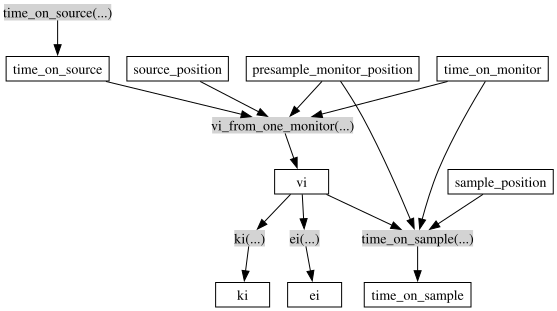

In [7]:
from dgs_reduction import calculate_ei

monitor_data = monitor_data.transform_coords(
    ["ki", "ei", "time_on_sample"],
    graph=calculate_ei,
    keep_intermediate=False,
)
display(monitor_data)
sc.show_graph(calculate_ei)

# Calculate the INS time windows (per pixel, per RRM)
By defualt, keep events where energy transfer E = Ei - Ef is within ±0.8*Ei. Events outside this range will be masked later. Notice that sample to detector distance varys, so the TOA windows are different per pxiel_id, per RRM.

In [7]:
from dgs_reduction import determine_INS_windows

norm_factors = determine_INS_windows(
    monitor_data, det_positions, energy_transfer_ratio=(-0.8, 0.8)
)
display(norm_factors)

<scipp.DataArray>
Dimensions: Sizes[pixel_id:44800, rrm:5, ]
Coordinates:
* detector_positions        vector3              [m]  (pixel_id)  [(-1.65177, -2.18399, 162.804), (-1.62368, -2.18399, 162.824), ..., (2.4633, 1.29142, 157.142), (2.43561, 1.29142, 157.122)]
* ei                        float64            [meV]  (rrm)  [1.37256e-11, 1.09086e-11, ..., 7.36519e-12, 6.20875e-12]
* ki                        vector3           [1/Å]  (rrm)  [(6.08163e-09, -7.18087e-09, 2.57368e-06), (5.42174e-09, -6.40171e-09, 2.29442e-06), ..., (4.45499e-09, -5.26022e-09, 1.8853e-06), (4.09031e-09, -4.82963e-09, 1.73098e-06)]
* monitor_counts            float64         [counts]  (rrm)  [861423, 1.5189e+06, ..., 1.42645e+06, 1.33317e+06]
  sample_position           vector3              [m]  ()  (0.37797, -0.446287, 159.953)
* time_on_sample            float64              [s]  (rrm)  [98709.1, 110723, ..., 134751, 146764]
* toa_max                   float64              [s]  (pixel_id, rrm)  [104101, 116771, ..., 142111, 154781]
* toa_min                   float64              [s]  (pixel_id, rrm)  [100506, 112739, ..., 137204, 149437]
Data:
                            float64  [dimensionless]  (pixel_id, rrm)  [0, 0, ..., 0, 0]

# Flatten the binned events, add pixel_id as coordinate

In [8]:
events_binned.bins.coords["pixel_id"] = sc.bins_like(
    events_binned.data, events_binned.coords["pixel_id"]
)
events = events_binned.bins.concat().value.copy()
events.coords["toa"] = events.coords.pop("t")
display(events)

<scipp.DataArray>
Dimensions: Sizes[events:1793080, ]
Coordinates:
* pixel_id                    int64  [dimensionless]  (events)  [0, 0, ..., 44704, 44704]
* toa                       float64              [s]  (events)  [0.15032, 0.150335, ..., 0.125673, 0.150285]
Data:
                            float64         [counts]  (events)  [0.0104593, 0.0104662, ..., 7.52885e-05, 0.014157]

# Assgin RRM index of TOA based on toa_min mask data between toa_max and toa_min

In [9]:
from dgs_reduction import assign_rrm

events = assign_rrm(events, norm_factors)
events

<scipp.DataArray>
Dimensions: Sizes[events:1793080, ]
Coordinates:
* detector_positions        vector3              [m]  (events)  [(-1.65177, -2.18399, 162.804), (-1.65177, -2.18399, 162.804), ..., (3.87763, 1.29157, 159.919), (3.87763, 1.29157, 159.919)]
* ei                        float64            [meV]  (events)  [6.20875e-12, 6.20875e-12, ..., 6.20875e-12, 6.20875e-12]
* ki                        vector3           [1/Å]  (events)  [(4.09031e-09, -4.82963e-09, 1.73098e-06), (4.09031e-09, -4.82963e-09, 1.73098e-06), ..., (4.09031e-09, -4.82963e-09, 1.73098e-06), (4.09031e-09, -4.82963e-09, 1.73098e-06)]
* pixel_id                    int64  [dimensionless]  (events)  [0, 0, ..., 44704, 44704]
* rrm                         int64  [dimensionless]  (events)  [4, 4, ..., 4, 4]
  sample_position           vector3              [m]  ()  (0.37797, -0.446287, 159.953)
* time_on_sample            float64              [s]  (events)  [146764, 146764, ..., 146764, 146764]
* toa                       float64              [s]  (events)  [0.15032, 0.150335, ..., 0.125673, 0.150285]
Data:
                            float64         [counts]  (events)  [0.0104593, 0.0104662, ..., 7.52885e-05, 0.014157]
Masks:
  outside                      bool        <no unit>  (events)  [True, True, ..., True, True]

# Convert from (pixel_id, toa) to (Q, E)

<scipp.DataArray>
Dimensions: Sizes[events:1793080, ]
Coordinates:
  detector_positions        vector3              [m]  (events)  [(-1.65177, -2.18399, 162.804), (-1.65177, -2.18399, 162.804), ..., (3.87763, 1.29157, 159.919), (3.87763, 1.29157, 159.919)]
  ef                        float64            [meV]  (events)  [3.7053e-15, 3.7053e-15, ..., 3.7053e-15, 3.7053e-15]
  ei                        float64            [meV]  (events)  [6.20875e-12, 6.20875e-12, ..., 6.20875e-12, 6.20875e-12]
* en                        float64            [meV]  (events)  [6.20505e-12, 6.20505e-12, ..., 6.20505e-12, 6.20505e-12]
* kf                        vector3           [1/Å]  (events)  [(2.19655e-08, 1.88051e-08, -3.08553e-08), (2.19655e-08, 1.88051e-08, -3.08553e-08), ..., (-3.78726e-08, -1.88068e-08, 3.64294e-10), (-3.78726e-08, -1.88068e-08, 3.64294e-10)]
  ki                        vector3           [1/Å]  (events)  [(4.09031e-09, -4.82963e-09, 1.73098e-06), (4.09031e-09, -4.82963e-09, 1.73098e-06), ..., (4.09031e-09, -4.82963e-09, 1.73098e-06), (4.09031e-09, -4.82963e-09, 1.73098e-06)]
* pixel_id                    int64  [dimensionless]  (events)  [0, 0, ..., 44704, 44704]
  q                         vector3           [1/Å]  (events)  [(-1.78752e-08, -2.36347e-08, 1.76183e-06), (-1.78752e-08, -2.36347e-08, 1.76183e-06), ..., (4.19629e-08, 1.39771e-08, 1.73061e-06), (4.1963e-08, 1.39772e-08, 1.73061e-06)]
* q_mag                     float64           [1/Å]  (events)  [1.76208e-06, 1.76208e-06, ..., 1.73118e-06, 1.73118e-06]
* qx                        float64           [1/Å]  (events)  [-1.78752e-08, -1.78752e-08, ..., 4.19629e-08, 4.1963e-08]
* qy                        float64           [1/Å]  (events)  [-2.36347e-08, -2.36347e-08, ..., 1.39771e-08, 1.39772e-08]
* qz                        float64           [1/Å]  (events)  [1.76183e-06, 1.76183e-06, ..., 1.73061e-06, 1.73061e-06]
* rrm                         int64  [dimensionless]  (events)  [4, 4, ..., 4, 4]
  sample_position           vector3              [m]  ()  (0.37797, -0.446287, 159.953)
  time_on_sample            float64              [s]  (events)  [146764, 146764, ..., 146764, 146764]
  toa                       float64              [s]  (events)  [0.15032, 0.150335, ..., 0.125673, 0.150285]
  vf                        vector3            [m/s]  (events)  [(1.383e-05, 1.18401e-05, -1.94272e-05), (1.383e-05, 1.18401e-05, -1.94272e-05), ..., (-2.38455e-05, -1.18412e-05, 2.29367e-07), (-2.38455e-05, -1.18412e-05, 2.29367e-07)]
Data:
                            float64         [counts]  (events)  [0.0104593, 0.0104662, ..., 7.52885e-05, 0.014157]
Masks:
  outside                      bool        <no unit>  (events)  [True, True, ..., True, True]

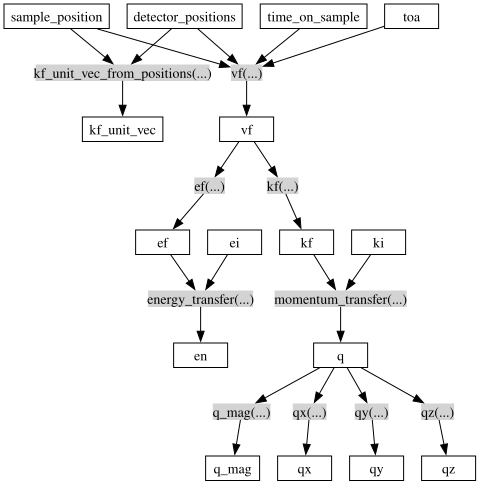

In [10]:
from dgs_reduction import calculate_qe

events = events.transform_coords(
    ["qx", "qy", "qz", "en", "q_mag", "kf"],
    graph=calculate_qe,
    keep_intermediate=True,
)
display(events)
sc.show_graph(calculate_qe)

# Plot events to check for coverage
Notice here we do not ditinguish diffferent RRMs, all events are used for histogramming

In [11]:
%matplotlib widget
import plopp as pp
from dgs_reduction import generate_bins, generate_plot_coords_and_title

grid = {
    "qx": (-2, 1.5, 0.1),
    "qy": (-2, 2, 0.1),
    "qz": (-1.0, 1.0),
    "en": (-0.2, 0.2),
}

bins = generate_bins(grid)
display(bins)

plot_coords, plot_title = generate_plot_coords_and_title(bins)

data_hist = sc.bin(events, **bins).hist()
display(data_hist)


{'qx': <scipp.Variable> (qx: 36)    float64           [1/Å]  [-2, -1.9, ..., 1.4, 1.5],
 'qy': <scipp.Variable> (qy: 41)    float64           [1/Å]  [-2, -1.9, ..., 1.9, 2],
 'qz': <scipp.Variable> (qz: 2)    float64           [1/Å]  [-1, 1],
 'en': <scipp.Variable> (en: 2)    float64            [meV]  [-0.2, 0.2]}

<scipp.DataArray>
Dimensions: Sizes[qx:35, qy:40, qz:1, en:1, ]
Coordinates:
* en                        float64            [meV]  (en [bin-edge])  [-0.2, 0.2]
* qx                        float64           [1/Å]  (qx [bin-edge])  [-2, -1.9, ..., 1.4, 1.5]
* qy                        float64           [1/Å]  (qy [bin-edge])  [-2, -1.9, ..., 1.9, 2]
* qz                        float64           [1/Å]  (qz [bin-edge])  [-1, 1]
  sample_position           vector3              [m]  ()  (0.37797, -0.446287, 159.953)
Data:
                            float64         [counts]  (qx, qy, qz, en)  [0, 0, ..., 0, 0]

In [12]:
pp.plot(
    data_hist.squeeze().transpose(),
    coords=plot_coords,
    grid=True,
    cmap="turbo",
    title=plot_title,
    vmin=0,
    vmax=1,
)

InteractiveFigure(children=(HBar(), HBar(children=(VBar(children=(Toolbar(children=(ButtonTool(icon='home', la…

In [13]:
grid = {
    "qx": (-2, 1.5, 0.1),
    "qy": (-1.0, 1.0),
    "qz": (-0.5, 2.5),
    "en": (-1, 1, 0.01),
}

bins = generate_bins(grid)
plot_coords, plot_title = generate_plot_coords_and_title(bins)

data_hist = sc.bin(events, **bins).hist()
display(data_hist)


<scipp.DataArray>
Dimensions: Sizes[qx:35, qy:1, qz:1, en:200, ]
Coordinates:
* en                        float64            [meV]  (en [bin-edge])  [-1, -0.99, ..., 0.99, 1]
* qx                        float64           [1/Å]  (qx [bin-edge])  [-2, -1.9, ..., 1.4, 1.5]
* qy                        float64           [1/Å]  (qy [bin-edge])  [-1, 1]
* qz                        float64           [1/Å]  (qz [bin-edge])  [-0.5, 2.5]
  sample_position           vector3              [m]  ()  (0.37797, -0.446287, 159.953)
Data:
                            float64         [counts]  (qx, qy, qz, en)  [0, 0, ..., 0, 0]

In [14]:
pp.plot(
    data_hist.squeeze().transpose(),
    coords=plot_coords,
    grid=True,
    cmap="turbo",
    vmin=0,
    vmax=0.5,
    title=plot_title,
)

InteractiveFigure(children=(HBar(), HBar(children=(VBar(children=(Toolbar(children=(ButtonTool(icon='home', la…

# Calculate normalization factors for histogramming (MDNorm)

# Calculate detector solid angles from a white beam Vanadium run (counts per pixel)

In [15]:
import os
import sys
import scipp as sc
import mcstastox as mx

parent = os.path.dirname(os.getcwd())
sys.path.append(parent)

parent = os.path.dirname(os.getcwd())
van_path = parent + "/runs/CSPEC_vanad_1e10"

with mx.Read(van_path) as mcstas_van_data:
    scipp_van_data_group = mcstas_van_data.export_scipp(
        source_name="ESS_Source",
        sample_name="Sample",
    )

v_events_binned = scipp_van_data_group["events"]
display(v_events_binned)
# Group by pixel_id to fill in the pixels that recorded no events
detector_posisitions = scipp_van_data_group["positions"]
sample_position = v_events_binned.coords["sample_position"]
v_events = v_events_binned.group(
    sc.arange(detector_posisitions.dim, 0, detector_posisitions.size)
)
display(v_events)

<scipp.DataArray>
Dimensions: Sizes[pixel_id:31499, ]
Coordinates:
* pixel_id                    int64  [dimensionless]  (pixel_id)  [0, 1, ..., 44703, 44704]
* position                  vector3              [m]  (pixel_id)  [(-1.65177, -2.18399, 162.804), (-1.62368, -2.18399, 162.824), ..., (3.87779, 1.29157, 159.954), (3.87763, 1.29157, 159.919)]
* sample_position           vector3              [m]  ()  (0.37797, -0.446287, 159.953)
* source_position           vector3              [m]  ()  (0, 0, 0)
Data:
                          DataArrayView        <no unit>  (pixel_id)  binned data: dim='events', content=DataArray(
          dims=(events: 1793080),
          data=float64[counts],
          coords={'t':float64[s]})

<scipp.DataArray>
Dimensions: Sizes[pixel_id:44800, ]
Coordinates:
* pixel_id                    int64  [dimensionless]  (pixel_id)  [0, 1, ..., 44798, 44799]
* sample_position           vector3              [m]  ()  (0.37797, -0.446287, 159.953)
* source_position           vector3              [m]  ()  (0, 0, 0)
Data:
                          DataArrayView        <no unit>  (pixel_id)  binned data: dim='events', content=DataArray(
          dims=(events: 1793080),
          data=float64[counts],
          coords={'t':float64[s]})

# Mask the leakage from beamstop

In [16]:
import numpy as np
# solid angles
# LET banana detectors
# Horizontal -40 to 140 degs, sample to detector distance is R = 3.5 m, 221 bins
# width per pixel is w = (140+40)/180*pi*R/384 =  0.02863 m
# Vertical height is H = 4 m, 256 bins
# height per pixel is h = H/256 = 0.015625 m
# height per pixel is h = H/136 = 0.0294 m
# solid angle Omega = 4*arctan(w*h/(2d*sqrt(4d^2+w^2+h^2)))
# d = sqrt(x^2+y^2+z^2)

d_omega_exp = v_events.hist().data
# mask = d_omega_exp > sc.scalar(0.0015, unit=d_omega_exp.unit)
# d_omega_exp = sc.where(mask, sc.scalar(np.nan, unit=d_omega_exp.unit), d_omega_exp)

d_omega_exp /= d_omega_exp.nansum()
print(d_omega_exp)
# norm_factors.coords["d_omega_exp"] = d_omega

<scipp.Variable> (pixel_id: 44800)    float64  [dimensionless]  [2.79534e-05, 2.1798e-05, ..., 0, 0]


# Visualize the Vanadium data

In [17]:
import plopp as pp

theta_bins=320
theta_limits=[-36, 144]
y_bins=140
yheight = 3.5

nx, ny = theta_bins, y_bins
v_cylinder = sc.DataArray(
    data=sc.Variable(
        dims=["height", "two_theta"], values=np.reshape(d_omega_exp.values, (ny, nx))
    ),
    coords={
        "two_theta": sc.linspace(dim="two_theta", start=theta_limits[0], stop=theta_limits[1], num=nx),
        "height": sc.linspace(dim="height", start=-yheight/2, stop=yheight/2, num=ny),
    },
)

pp.plot(
    v_cylinder, title="Vanadium cylinder", vmin=0, vmax=1.5e-4, cmap="turbo", grid=True
)

InteractiveFigure(children=(HBar(), HBar(children=(VBar(children=(Toolbar(children=(ButtonTool(icon='home', la…

<scipp.DataArray>
Dimensions: Sizes[pixel_id:44800, ]
Coordinates:
  detector_geometry          string        <no unit>  ()  "cylinder"
  pixel_height              float64              [m]  ()  0.025
* pixel_id                    int64  [dimensionless]  (pixel_id)  [0, 1, ..., 44798, 44799]
  pixel_position            vector3              [m]  (pixel_id)  [(-2.02974, -1.7377, 2.85122), (-2.00165, -1.7377, 2.87101), ..., (2.08533, 1.73771, -2.81081), (2.05764, 1.73771, -2.83115)]
* pixel_solid_angle         float64             [sr]  (pixel_id)  [5.03901e-05, 5.03902e-05, ..., 5.03901e-05, 5.03901e-05]
  pixel_width               float64              [m]  ()  0.034361
* sample_position           vector3              [m]  ()  (0.37797, -0.446287, 159.953)
* source_position           vector3              [m]  ()  (0, 0, 0)
Data:
                          DataArrayView        <no unit>  (pixel_id)  binned data: dim='events', content=DataArray(
          dims=(events: 1793080),
          data=float64[counts],
          coords={'t':float64[s]})

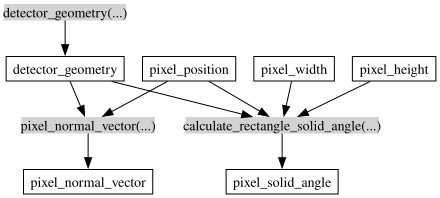

In [18]:
from reduction.dgs_reduction import calculate_solid_angle

h = sc.norm(detector_posisitions[320] - detector_posisitions[0])
w = sc.norm(detector_posisitions[1] - detector_posisitions[0])
r = detector_posisitions - sample_position

v_events.coords["pixel_position"] = r
v_events.coords["pixel_height"] = h
v_events.coords["pixel_width"] = w
v_events = v_events.transform_coords(
    [
        "pixel_solid_angle",
    ],
    graph=calculate_solid_angle,
)
display(v_events)
sc.show_graph(calculate_solid_angle)

In [19]:
pp.plot(
    {
        "McStas": d_omega_exp,
        "Calc": v_events.coords["pixel_solid_angle"]
        / sc.sum(v_events.coords["pixel_solid_angle"]),
    },
    ylabel="fractional counts",
    title="Vanadium counts/pixel over total counts",
    linestyle="-",
    markersize=2,
    #ymax=2e-5,
    ymin=0.0,
    grid=True,
)

InteractiveFigure(children=(HBar(), HBar(children=(VBar(children=(Toolbar(children=(ButtonTool(icon='home', la…

In [20]:
norm_factors.coords["d_omega"] = v_events.coords["pixel_solid_angle"]
norm_factors

<scipp.DataArray>
Dimensions: Sizes[pixel_id:44800, rrm:5, ]
Coordinates:
* d_omega                   float64             [sr]  (pixel_id)  [5.03901e-05, 5.03902e-05, ..., 5.03901e-05, 5.03901e-05]
* detector_positions        vector3              [m]  (pixel_id)  [(-1.65177, -2.18399, 162.804), (-1.62368, -2.18399, 162.824), ..., (2.4633, 1.29142, 157.142), (2.43561, 1.29142, 157.122)]
* ei                        float64            [meV]  (rrm)  [1.37256e-11, 1.09086e-11, ..., 7.36519e-12, 6.20875e-12]
* ki                        vector3           [1/Å]  (rrm)  [(6.08163e-09, -7.18087e-09, 2.57368e-06), (5.42174e-09, -6.40171e-09, 2.29442e-06), ..., (4.45499e-09, -5.26022e-09, 1.8853e-06), (4.09031e-09, -4.82963e-09, 1.73098e-06)]
* monitor_counts            float64         [counts]  (rrm)  [861423, 1.5189e+06, ..., 1.42645e+06, 1.33317e+06]
  sample_position           vector3              [m]  ()  (0.37797, -0.446287, 159.953)
* time_on_sample            float64              [s]  (rrm)  [98709.1, 110723, ..., 134751, 146764]
* toa_max                   float64              [s]  (pixel_id, rrm)  [104101, 116771, ..., 142111, 154781]
* toa_min                   float64              [s]  (pixel_id, rrm)  [100506, 112739, ..., 137204, 149437]
Data:
                            float64  [dimensionless]  (pixel_id, rrm)  [0, 0, ..., 0, 0]

# Calculate detector trajectory endpoints (per pixel, per RRM)

<scipp.DataArray>
Dimensions: Sizes[pixel_id:44800, rrm:5, ]
Coordinates:
* d_omega                   float64             [sr]  (pixel_id)  [5.03901e-05, 5.03902e-05, ..., 5.03901e-05, 5.03901e-05]
  detector_positions        vector3              [m]  (pixel_id)  [(-1.65177, -2.18399, 162.804), (-1.62368, -2.18399, 162.824), ..., (2.4633, 1.29142, 157.142), (2.43561, 1.29142, 157.122)]
  ef_gain                   float64            [meV]  (pixel_id, rrm)  [2.47061e-11, 1.96355e-11, ..., 1.32573e-11, 1.11758e-11]
  ef_loss                   float64            [meV]  (pixel_id, rrm)  [2.74512e-12, 2.18172e-12, ..., 1.47304e-12, 1.24175e-12]
  ei                        float64            [meV]  (rrm)  [1.37256e-11, 1.09086e-11, ..., 7.36519e-12, 6.20875e-12]
* energy_gain_ratio         float64  [dimensionless]  (pixel_id, rrm)  [-0.8, -0.8, ..., -0.8, -0.8]
* energy_loss_ratio         float64  [dimensionless]  (pixel_id, rrm)  [0.8, 0.8, ..., 0.8, 0.8]
* kf_M                      vector3           [1/Å]  (pixel_id, rrm)  [(-1.79362e-06, -1.53556e-06, 2.51953e-06), (-1.59901e-06, -1.36894e-06, 2.24615e-06), ..., (1.33194e-06, 1.12485e-06, -1.83265e-06), (1.22291e-06, 1.03277e-06, -1.68263e-06)]
  kf_M_mag                  float64           [1/Å]  (pixel_id, rrm)  [3.45298e-06, 3.07831e-06, ..., 2.52942e-06, 2.32236e-06]
* kf_m                      vector3           [1/Å]  (pixel_id, rrm)  [(-5.97874e-07, -5.11852e-07, 8.39844e-07), (-5.33002e-07, -4.56313e-07, 7.48717e-07), ..., (4.4398e-07, 3.74948e-07, -6.10883e-07), (4.07637e-07, 3.44256e-07, -5.60878e-07)]
  kf_m_mag                  float64           [1/Å]  (pixel_id, rrm)  [1.15099e-06, 1.0261e-06, ..., 8.43139e-07, 7.74122e-07]
  kf_unit_vec               vector3  [dimensionless]  (pixel_id)  [(-0.519442, -0.444705, 0.72967), (-0.512254, -0.444704, 0.734734), ..., (0.533668, 0.444706, -0.719329), (0.52658, 0.444705, -0.724534)]
  ki                        vector3           [1/Å]  (rrm)  [(6.08163e-09, -7.18087e-09, 2.57368e-06), (5.42174e-09, -6.40171e-09, 2.29442e-06), ..., (4.45499e-09, -5.26022e-09, 1.8853e-06), (4.09031e-09, -4.82963e-09, 1.73098e-06)]
* monitor_counts            float64         [counts]  (rrm)  [861423, 1.5189e+06, ..., 1.42645e+06, 1.33317e+06]
* q_M                       vector3           [1/Å]  (pixel_id, rrm)  [(1.7997e-06, 1.52837e-06, 5.41478e-08), (1.60443e-06, 1.36254e-06, 4.82725e-08), ..., (-1.32749e-06, -1.13011e-06, 3.71795e-06), (-1.21882e-06, -1.0376e-06, 3.41361e-06)]
* q_m                       vector3           [1/Å]  (pixel_id, rrm)  [(6.03956e-07, 5.04671e-07, 1.73384e-06), (5.38423e-07, 4.49912e-07, 1.54571e-06), ..., (-4.39525e-07, -3.80209e-07, 2.49619e-06), (-4.03547e-07, -3.49086e-07, 2.29185e-06)]
  sample_position           vector3              [m]  ()  (0.37797, -0.446287, 159.953)
  time_on_sample            float64              [s]  (rrm)  [98709.1, 110723, ..., 134751, 146764]
  toa_max                   float64              [s]  (pixel_id, rrm)  [104101, 116771, ..., 142111, 154781]
  toa_min                   float64              [s]  (pixel_id, rrm)  [100506, 112739, ..., 137204, 149437]
Data:
                            float64  [dimensionless]  (pixel_id, rrm)  [0, 0, ..., 0, 0]

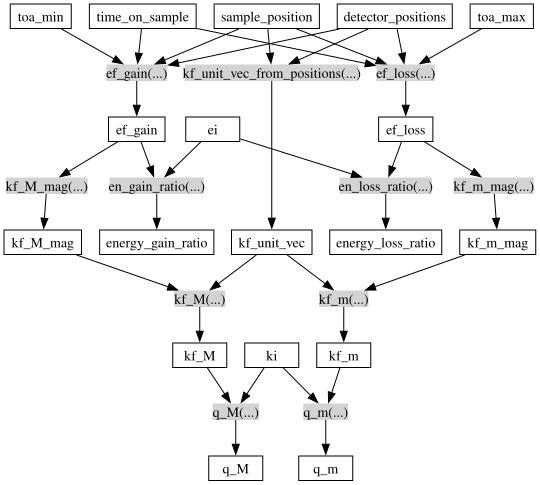

In [21]:
from dgs_reduction import calculate_trajectory_endpoints

norm_factors = norm_factors.transform_coords(
    [
        "energy_gain_ratio",
        "energy_loss_ratio",
        "kf_m",
        "kf_M",
        "q_m",
        "q_M",
    ],
    graph=calculate_trajectory_endpoints,
)
display(norm_factors)
sc.show_graph(calculate_trajectory_endpoints)

In [22]:
from dgs_reduction import mdnorm

grid = {
    "qx": (-2, 1.5, 0.1),
    "qy": (-2, 2, 0.1),
    "qz": (-1.0, 1.0),
    "en": (-0.2, 0.2),
}

rrm = 1
data, plot_coords, plot_title = mdnorm(events, grid, norm_factors, rrm=rrm)

In [23]:
pp.plot(
    data,
    coords=plot_coords,
    grid=True,
    cmap="turbo",
    vmin=0,
    vmax=5e-3,
    title=plot_title,
)

InteractiveFigure(children=(HBar(), HBar(children=(VBar(children=(Toolbar(children=(ButtonTool(icon='home', la…

In [24]:
grid = {
    "qx": (-2, 1.5, 0.1),
    "qy": (-2, 2, 0.1),
    "qz": (-1.0, 1.0),
    "en": (2.0, 2.2),
}

data, plot_coords, plot_title = mdnorm(events, grid, norm_factors, rrm=rrm)

In [25]:
pp.plot(
    data,
    coords=plot_coords,
    grid=True,
    cmap="turbo",
    vmin=0,
    vmax=5e-3,
    title=plot_title,
)

InteractiveFigure(children=(HBar(), HBar(children=(VBar(children=(Toolbar(children=(ButtonTool(icon='home', la…

In [26]:
grid = {
    "qx": (-2, 1.5, 0.1),
    "qy": (-0.1, 0.1),
    "qz": (-1, 3.0, 0.1),
    "en": (-0.2, 0.2),
}

data, plot_coords, plot_title = mdnorm(events, grid, norm_factors, rrm=rrm)

In [27]:
pp.plot(
    data,
    coords=plot_coords,
    grid=True,
    cmap="turbo",
    vmin=0,
    vmax=5e-3,
    title=plot_title,
)

InteractiveFigure(children=(HBar(), HBar(children=(VBar(children=(Toolbar(children=(ButtonTool(icon='home', la…

In [28]:
grid = {
    "qx": (-2, 1.5, 0.1),
    "qy": (-0.1, 0.1),
    "qz": (-1, 3.0, 0.1),
    "en": (2.0, 2.2),
}

data, plot_coords, plot_title = mdnorm(
    events,
    grid,
    norm_factors,
    rrm=rrm,
)

In [29]:
pp.plot(
    data,
    coords=plot_coords,
    grid=True,
    cmap="turbo",
    vmin=0,
    vmax=5e-3,
    title=plot_title,
)

InteractiveFigure(children=(HBar(), HBar(children=(VBar(children=(Toolbar(children=(ButtonTool(icon='home', la…

# averaging over a large Q ranges is very slow

In [30]:
grid = {
    "qx": (-1.5, 1.0),
    "qy": (-1.0, 1.0),
    "qz": (-0.5, 2.5, 0.1),
    "en": (-4, 4, 0.02),
}

data, plot_coords, plot_title = mdnorm(events, grid, norm_factors, rrm=rrm)

In [31]:
pp.plot(
    data,
    coords=plot_coords,
    grid=True,
    cmap="turbo",
    vmin=0,
    vmax=5e-3,
    title=plot_title,
)

InteractiveFigure(children=(HBar(), HBar(children=(VBar(children=(Toolbar(children=(ButtonTool(icon='home', la…

# Plot a 1D cut

In [32]:
grid = {
    "qx": (-1.5, 1.0),
    "qy": (-1.0, 1.0),
    "qz": (-0.5, 2.5),
    "en": (-4, 4, 0.02),
}

data, plot_coords, plot_title = mdnorm(events, grid, norm_factors, rrm=rrm)

In [33]:
data

<scipp.DataArray>
Dimensions: Sizes[en:400, ]
Coordinates:
* en                        float64            [meV]  (en [bin-edge])  [-4, -3.98, ..., 3.98, 4]
  qx                        float64           [1/Å]  (qx [bin-edge])  [-1.5, 1]
  qy                        float64           [1/Å]  (qy [bin-edge])  [-1, 1]
  qz                        float64           [1/Å]  (qz [bin-edge])  [-0.5, 2.5]
Data:
                            float64       [1/sr/meV]  (en)  [nan, nan, ..., nan, nan]

In [34]:
data2 = data.copy()
data2.variances = data2.data.values / 20
data2

<scipp.DataArray>
Dimensions: Sizes[en:400, ]
Coordinates:
* en                        float64            [meV]  (en [bin-edge])  [-4, -3.98, ..., 3.98, 4]
  qx                        float64           [1/Å]  (qx [bin-edge])  [-1.5, 1]
  qy                        float64           [1/Å]  (qy [bin-edge])  [-1, 1]
  qz                        float64           [1/Å]  (qz [bin-edge])  [-0.5, 2.5]
Data:
                            float64       [1/sr/meV]  (en)  [nan, nan, ..., nan, nan]  [nan, nan, ..., nan, nan]

In [35]:
pp.plot(
    data2,
    marker="o",
    ls=None,
    coords=plot_coords,
    grid=True,
    cmap="turbo",
    vmin=0,
    vmax=0.8,
    title=plot_title,
)

InteractiveFigure(children=(HBar(), HBar(children=(VBar(children=(Toolbar(children=(ButtonTool(icon='home', la…

In [36]:
pp.plot(
    data,
    coords=plot_coords,
    grid=True,
    cmap="turbo",
    vmin=0,
    vmax=0.8,
    title=plot_title,
)

InteractiveFigure(children=(HBar(), HBar(children=(VBar(children=(Toolbar(children=(ButtonTool(icon='home', la…

In [37]:
grid = {
    "qx": (-1.5, 1.0, 0.05),
    "qy": (-1.0, 1.0),
    "qz": (-0.0, 1.0),
    "en": (-0.2, 0.2, 0.005),
}

data, plot_coords, plot_title = mdnorm(events, grid, norm_factors, rrm=rrm)

In [38]:
pp.plot(
    data,
    coords=plot_coords,
    grid=True,
    cmap="turbo",
    vmin=0,
    vmax=5e-3,
    title=plot_title,
)

InteractiveFigure(children=(HBar(), HBar(children=(VBar(children=(Toolbar(children=(ButtonTool(icon='home', la…

# Plot |Q| vs. E for powder samples

In [39]:
grid = {
    "qx": (-2.5, 2.0, 0.1),
    "qy": (-2.0, 2.0, 0.1),
    "qz": (-1.5, 2.5, 0.1),
    "en": (-4, 4, 0.005),
}

data4d, plot_coords, plot_title = mdnorm(events, grid, norm_factors, rrm=rrm)

mag_q = sc.sqrt(
    sc.midpoints(data4d.coords["qx"]) ** 2
    + sc.midpoints(data4d.coords["qy"]) ** 2
    + sc.midpoints(data4d.coords["qz"]) ** 2
)

data4d.coords["mag_q"] = mag_q
data4d

KeyboardInterrupt: 

In [ ]:
q_bins = sc.linspace("mag_q", 0.0, 3.0, num=100, unit="1/Å")
rebinned = data4d.bin(mag_q=q_bins)
data_rebinned = rebinned.bins.nanmean()
display(data_rebinned)

pp.plot(
    data_rebinned,
    grid=True,
    cmap="turbo",
    vmin=0,
    vmax=5e-3,
    title=plot_title,
)

<scipp.DataArray>
Dimensions: Sizes[en:1600, mag_q:99, ]
Coordinates:
* en                        float64            [meV]  (en [bin-edge])  [-4, -3.995, ..., 3.995, 4]
* mag_q                     float64           [1/Å]  (mag_q [bin-edge])  [0, 0.030303, ..., 2.9697, 3]
Data:
                            float64       [1/sr/meV]  (en, mag_q)  [nan, nan, ..., nan, nan]

InteractiveFigure(children=(HBar(), HBar(children=(VBar(children=(Toolbar(children=(ButtonTool(icon='home', la…

In [ ]:
plot_title

'qx=(-2.5, 1) [1/Å], qy=(-2, 1) [1/Å]\nqz=(-1.5, 1.5) [1/Å], en=(-4, 3.95) [meV]'